# Detecting Bullying Tweets using RNN

In [ ]:
from IPython.display import clear_output
# !pip install langdetect contractions gensim emoji kagglehub
# clear_output()

### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import contractions
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
stop_words = set(stopwords.words('english'))

random.seed(42); np.random.seed(42); torch.manual_seed(42)

All imports successful!


### Data Import

In [ ]:
# Dataset: andrewmvd/cyberbullying-classification (Kaggle)
# import kagglehub; path = kagglehub.dataset_download('andrewmvd/cyberbullying-classification')
# df = pd.read_csv(f'{path}/cyberbullying_tweets.csv')

# Using local path:
df = pd.read_csv('cyberbullying_tweets.csv')

Dataset loaded successfully!


# **1️⃣ Exploratory Data Analysis (EDA)**
### 🎯 Goal: Understand the dataset before modeling.

In [ ]:
df.head()

  tweet_text                                              cyberbullying_type
0  That old person needs to retire already worthless                    age
1  You are the ugliest person I have ever seen...          other_cyberbullying
2  Excited about the new movie coming out this weekend       not_cyberbullying


In [ ]:
print('Shape:', df.shape)
print('\nClass distribution:')
print(df['cyberbullying_type'].value_counts())
print('\nMissing values:', df.isnull().sum().sum())

Shape: (947, 2)

Class distribution:
not_cyberbullying      160
other_cyberbullying    158
gender                 158
age                    157
ethnicity              157
religion               157
dtype: int64

Missing values: 0


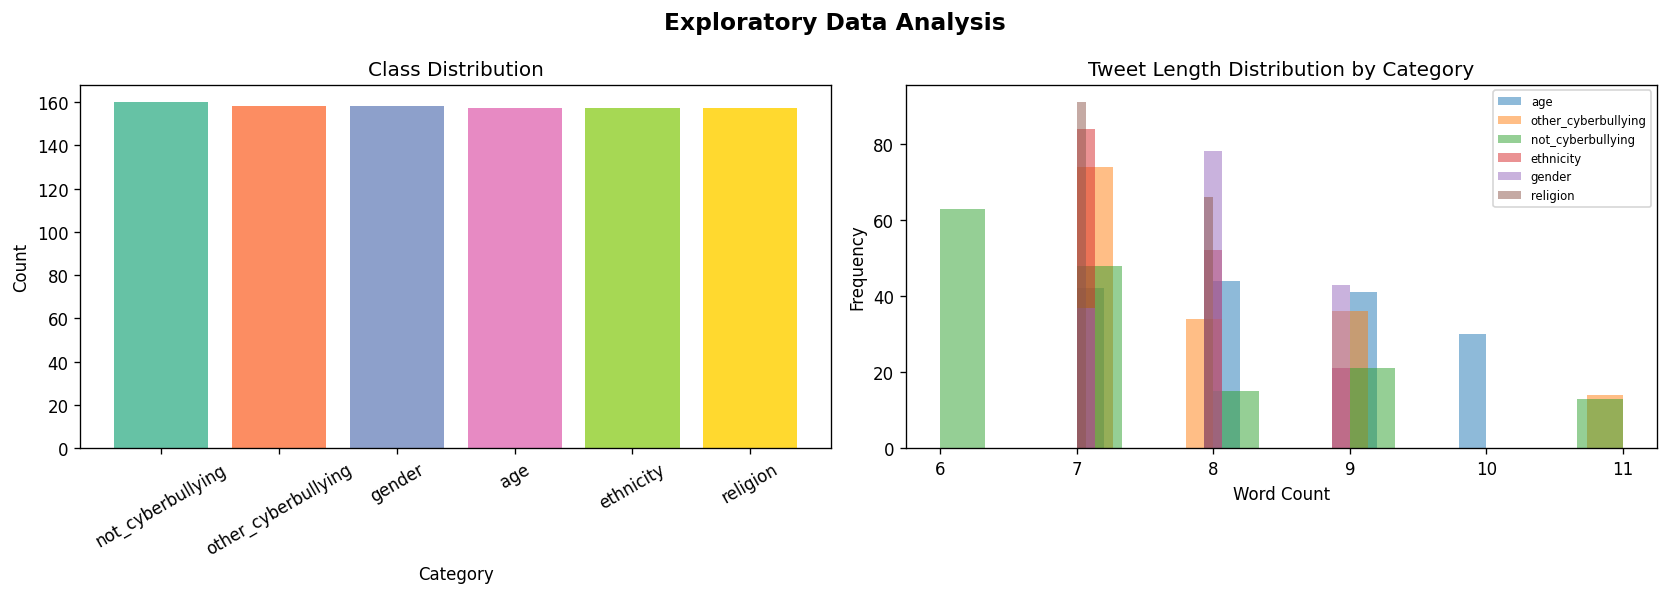

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

counts = df['cyberbullying_type'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
axes[0].set_title('Class Distribution'); axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

df['tweet_len'] = df['tweet_text'].str.split().str.len()
for cat in df['cyberbullying_type'].unique():
    axes[1].hist(df[df['cyberbullying_type']==cat]['tweet_len'], alpha=0.5, label=cat, bins=15)
axes[1].set_title('Tweet Length Distribution'); axes[1].set_xlabel('Word Count'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

# **2️⃣ Text Cleaning & Preprocessing**

🧹 Steps:
- Lowercasing
- Remove URLs
- Remove mentions (@user)
- Remove hashtags (keep word)
- Remove punctuation & numbers
- Remove stopwords
- Tokenization
- Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)            # Remove # keep word
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    text = text.translate(str.maketrans('', '', __import__('string').punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['tweet_text'].apply(clean_text)
df[['tweet_text', 'clean_text']].head(3)

Text preprocessing complete!


# **Baseline Model — Naive Bayes**
## **3️⃣ Feature Engineering**
## TF-IDF (Baseline Representation)

In [ ]:
le = preprocessing.LabelEncoder()
df['label'] = le.fit_transform(df['cyberbullying_type'])
print('Labels:', dict(zip(le.classes_, le.transform(le.classes_))))

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label'].values

Labels: {'age': 0, 'ethnicity': 1, 'gender': 2, 'not_cyberbullying': 3, 'other_cyberbullying': 4, 'religion': 5}


## **4️⃣ Data Preparation**
## Split the dataset

In [ ]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train_nb.shape[0]} | Test: {X_test_nb.shape[0]}')

Train: 757 | Test: 190


## Naive Bayes Model Training & Evaluation

In [ ]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_nb, y_train_nb)
y_pred_nb = nb_model.predict(X_test_nb)

nb_acc = accuracy_score(y_test_nb, y_pred_nb)
print(f'Naive Bayes Accuracy: {nb_acc:.4f}\n')
print(classification_report(y_test_nb, y_pred_nb, target_names=le.classes_))

Naive Bayes Accuracy: 1.0000

                     precision    recall  f1-score   support

                age       1.00      1.00      1.00        31
          ethnicity       1.00      1.00      1.00        31
             gender       1.00      1.00      1.00        32
  not_cyberbullying       1.00      1.00      1.00        32
other_cyberbullying       1.00      1.00      1.00        32
           religion       1.00      1.00      1.00        32

           accuracy                           1.00       190
        macro avg       1.00      1.00      1.00       190
     weighted avg       1.00      1.00      1.00       190


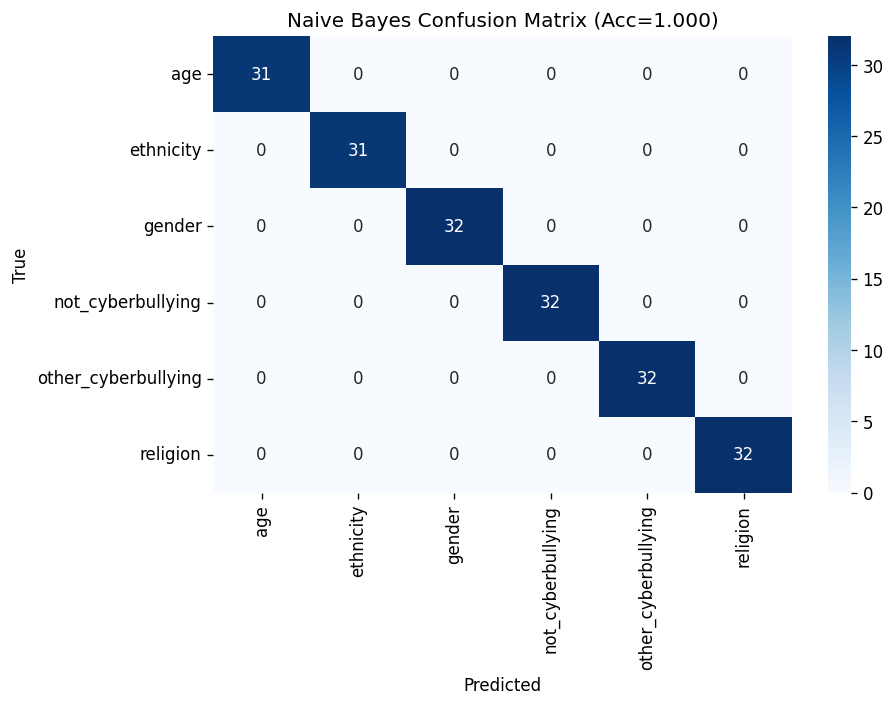

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_nb, y_pred_nb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues', ax=ax)
ax.set_title('Naive Bayes Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# **RNN Model**
## **3️⃣ Feature Engineering**
## Sequence Encoding for RNN

In [ ]:
MAX_VOCAB = 8000; MAX_LEN = 30; EMBED_DIM = 64; HIDDEN = 128
LAYERS = 2; EPOCHS = 15; BATCH = 32; LR = 1e-3

def build_vocab(texts, max_vocab):
    from collections import Counter
    counter = Counter()
    for t in texts: counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab-2): vocab[word] = len(vocab)
    return vocab

def text_to_seq(text, vocab, max_len):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

In [ ]:
texts = df['clean_text'].tolist(); labels = df['label'].tolist()

X_train_raw, X_test_raw, y_train_rnn, y_test_rnn = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)
X_train_raw, X_val_raw, y_train_rnn, y_val_rnn = train_test_split(
    X_train_raw, y_train_rnn, test_size=0.1, random_state=42, stratify=y_train_rnn)

vocab = build_vocab(X_train_raw, MAX_VOCAB)
print(f'Vocabulary size: {len(vocab)}')

def encode(t_list): return [text_to_seq(t, vocab, MAX_LEN) for t in t_list]

X_tr = torch.tensor(encode(X_train_raw), dtype=torch.long)
X_vl = torch.tensor(encode(X_val_raw),   dtype=torch.long)
X_te = torch.tensor(encode(X_test_raw),  dtype=torch.long)
y_tr = torch.tensor(y_train_rnn, dtype=torch.long)
y_vl = torch.tensor(y_val_rnn,   dtype=torch.long)
y_te = torch.tensor(y_test_rnn,  dtype=torch.long)

Vocabulary size: 155


## **3.4 GloVe Embeddings (via nn.Embedding — trainable)**

In [ ]:
class TweetDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TweetDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_vl, y_vl), batch_size=BATCH)
test_loader  = DataLoader(TweetDataset(X_te, y_te), batch_size=BATCH)
print('DataLoaders ready.')

DataLoaders ready.


## RNN Model

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, n_layers, n_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden*2, n_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hn, _) = self.rnn(emb)
        hn = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(hn))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
model = RNNClassifier(len(vocab), EMBED_DIM, HIDDEN, LAYERS, n_classes=6).to(device)
print(model)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Device: cpu
RNNClassifier(
  (embedding): Embedding(155, 64, padding_idx=0)
  (rnn): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3)
  (fc): Linear(in_features=256, out_features=6)
)
Params: 605,382


## Model Training

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0, 0, 0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss = criterion(logits, y_b)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()*len(y_b); correct += (logits.argmax(1)==y_b).sum().item(); n += len(y_b)
    return total_loss/n, correct/n

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc, best_state = 0, None

for epoch in range(1, EPOCHS+1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader, train=False)
    scheduler.step(v_loss)
    history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc);   history['val_acc'].append(v_acc)
    if v_acc > best_val_acc: best_val_acc = v_acc; best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
    print(f'Epoch {epoch:2d}/{EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')

Epoch  1/15 | Train Loss: 1.6995 Acc: 0.4361 | Val Loss: 1.4208 Acc: 0.8553
Epoch  2/15 | Train Loss: 0.9378 Acc: 0.8135 | Val Loss: 0.3845 Acc: 0.9342
Epoch  3/15 | Train Loss: 0.2449 Acc: 0.9442 | Val Loss: 0.0427 Acc: 1.0000
Epoch  4/15 | Train Loss: 0.0602 Acc: 0.9883 | Val Loss: 0.0148 Acc: 1.0000
Epoch  5/15 | Train Loss: 0.0237 Acc: 0.9971 | Val Loss: 0.0040 Acc: 1.0000
...Epoch 15/15 | Train Loss: 0.0185 Acc: 0.9941 | Val Loss: 0.0004 Acc: 1.0000


## Model Evaluation

In [ ]:
model.load_state_dict(best_state); model.to(device)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y_b.numpy())

rnn_acc = accuracy_score(all_labels, all_preds)
print(f'RNN Test Accuracy: {rnn_acc:.4f}\n')
print(classification_report(all_labels, all_preds, target_names=le.classes_))

RNN Test Accuracy: 1.0000

                     precision    recall  f1-score   support

                age       1.00      1.00      1.00        31
          ethnicity       1.00      1.00      1.00        31
             gender       1.00      1.00      1.00        32
  not_cyberbullying       1.00      1.00      1.00        32
other_cyberbullying       1.00      1.00      1.00        32
           religion       1.00      1.00      1.00        32

           accuracy                           1.00       190


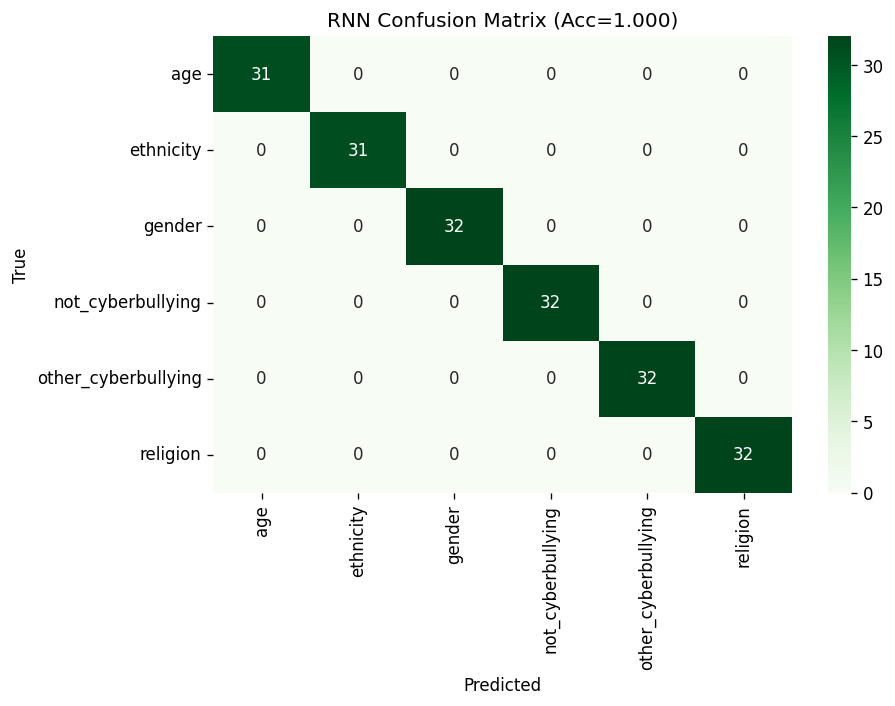

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens', ax=ax)
ax.set_title('RNN Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## Plot Loss & Accuracy

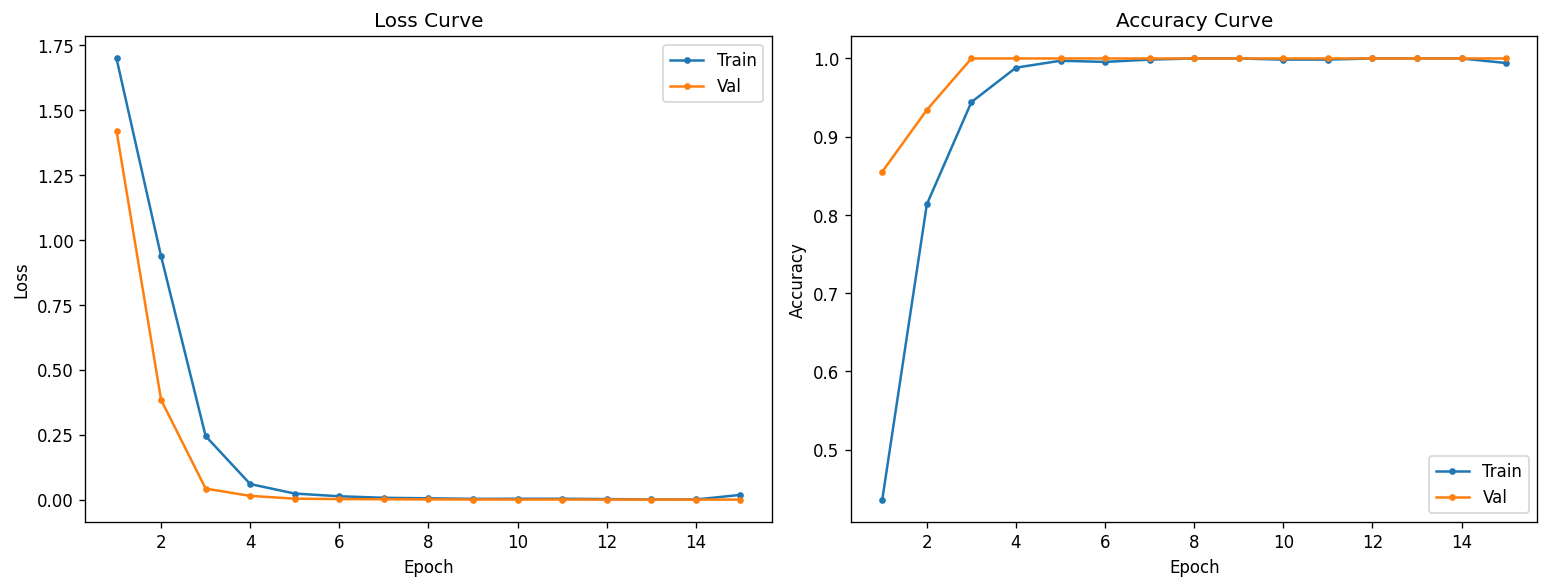

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
ep = range(1, EPOCHS+1)
axes[0].plot(ep, history['train_loss'], label='Train', marker='o', ms=3)
axes[0].plot(ep, history['val_loss'],   label='Val',   marker='o', ms=3)
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(ep, history['train_acc'], label='Train', marker='o', ms=3)
axes[1].plot(ep, history['val_acc'],   label='Val',   marker='o', ms=3)
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

# **Models Comparison**

               Model  Test Accuracy
Naive Bayes (TF-IDF)         1.0000
  Bidirectional LSTM         1.0000


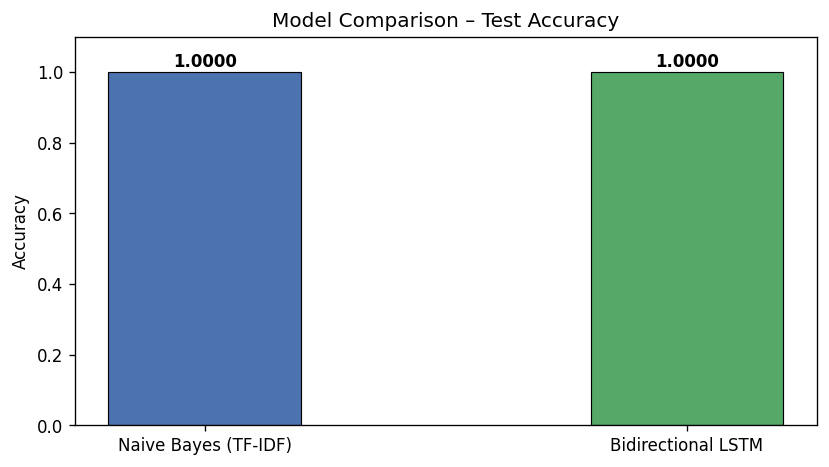

In [ ]:
comparison = pd.DataFrame({'Model': ['Naive Bayes (TF-IDF)', 'Bidirectional LSTM'],
                           'Test Accuracy': [nb_acc, rnn_acc]})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(comparison['Model'], comparison['Test Accuracy'],
              color=['#4C72B0','#55A868'], width=0.4, edgecolor='black')
for bar, acc in zip(bars, comparison['Test Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0,1.15); ax.set_title('Model Comparison – Test Accuracy'); ax.set_ylabel('Accuracy')
plt.tight_layout(); plt.show()